### **Report Details**

* **Student:** Ahmed Al-Muharaq
* **Professor:** Salomon Michel
* **Course:** Machine Learning
* **Program:** Master 1 - Embedded Computing Systems (IoT)
* **Institution:** Université Marie & Louis Pasteur (UMLP), EIPHI Graduate School
* **Module/Topic:** Lab 2 Review

# Solving a regression problem using decision trees and random forests

In this lab we'll use tow different kinds of machine learning methods to solve a regression problem. The considered problem is one for which the data set can be loaded directly using scikit-learn.

More about

*   Decision Trees - [scikit-learn](https://scikit-learn.org/stable/modules/tree.html)
*   Random Forests - [scikit-learn](https://scikit-learn.org/stable/modules/ensemble.html#random-forests-and-other-randomized-tree-ensembles)

## 1 - Some metrics used with regression problems

Suppose we want to evaluate these metrics on a set (assuming a single output value)
$$\left(Y_j,Y^t_j\right)_{j \in \{1,\dots,n\}}$$ where $Y_j$ is the predicted output and $Y^t_j$ the original target output.

*   **Max Error** defined as $\mbox{ME}=\max_{j \in \{1,\dots,n\}} |Y_j-Y^t_j|$. Unfortunately usually it is does correctly reflect the performance.
*   **Mean Absolute Error** defined as $\mbox{MAE}=\frac{1}{n} \sum_{j \in \{1,\dots,n\}} |Y_j-Y^t_j|$
*   **Mean Squared Error** defined as $\mbox{MSE}=\frac{1}{n} \sum_{j \in \{1,\dots,n\}} (Y_j-Y^t_j)^2$
*   **$R^2$ score** is defined by $$R^2 = 1 - \frac{\sum_{j \in \{1,\dots,n\}}\left(Y_j-Y^t_j\right)^2}{\sum_{j \in \{1,\dots,n\}} \left(\bar{Y}-Y^t_j\right)^2}$$ where $\bar{Y}$ represents the mean of $Y_j$.
$R^2$ is between $0$ and $1$ and the closer it is to $1$, the best the classifier.



## 2 - Decision Trees learning explained: [Machine Learning / David Gerbing](https://web.pdx.edu/~gerbing/Books/ML/) and [Wikipedia](https://en.wikipedia.org/wiki/Decision_tree_learning)

## 3 - Random Forests explained : [Wikipedia](https://en.wikipedia.org/wiki/Random_forest)


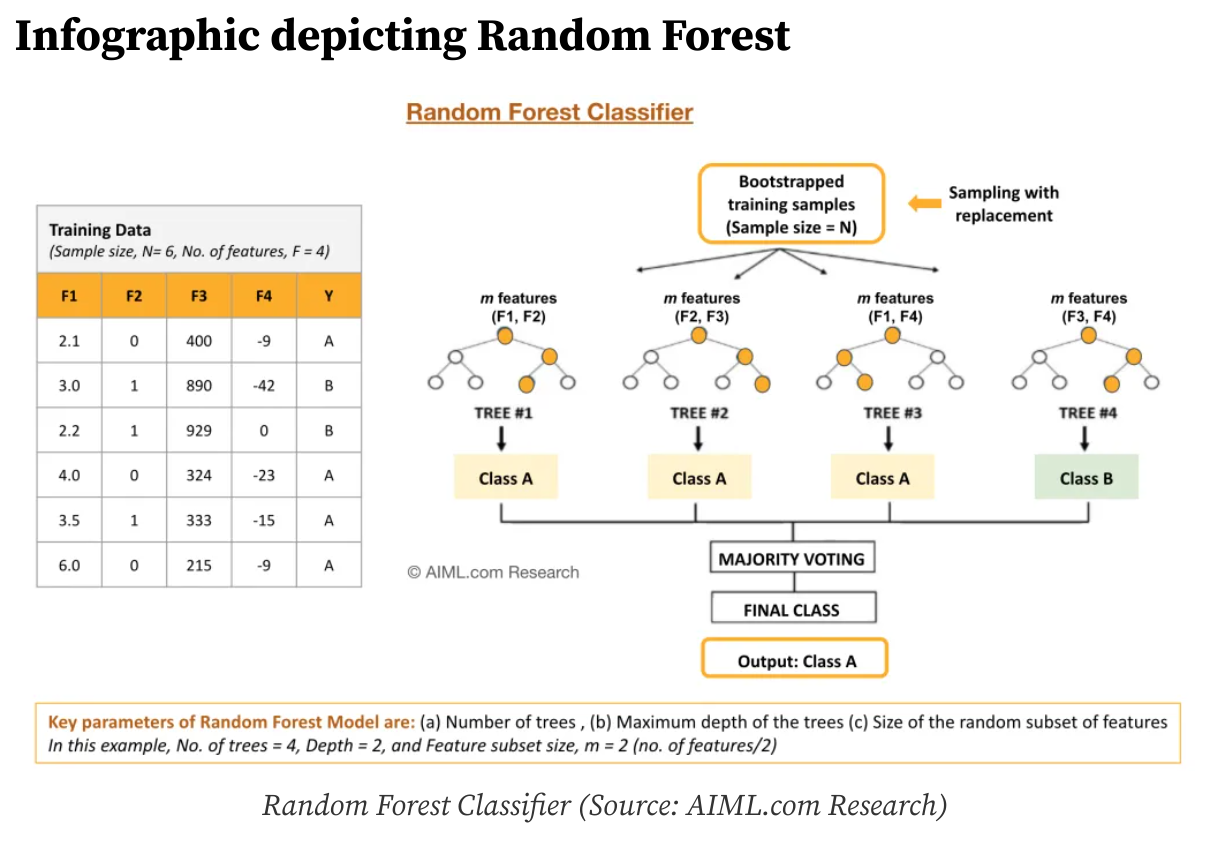

# What are you going to do?

In this Colab notebook you have to complete following steps:
1.   Load the boston data set. What kind of data does it contain?
2.   Train a regression Decision Tree to predict real estate value.
3.   Train several decision trees using increasing max_depth values.
4.   Train Random Forests by varying the max_depth value as done previously for decision tree.
5.   Show that scikit-learn simply averages the trees predictions of the forest.
6.   Rather than averaging the predictions of the different trees, uses Linear Regression to give them different weights
7.


## 1 - Load the boston data set

In [1]:
try:
    from sklearn.datasets import load_boston
    data = load_boston()
    X, y = data.data, data.target
except (ImportError, AttributeError):
    print("load_boston is removed in modern scikit-learn; using alternative in Cell 7.")

load_boston is removed in modern scikit-learn; using alternative in Cell 7.


In [2]:
# 1 - To find how to load the data set try to load the boston data set from scikit-learn
import pandas as pd
import numpy as np

# Since load_boston() was deprecated, load from original CMU repository
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]
feature_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_943/292298278.py:7: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


The inputs / features names are as follows:

* CRIM - per capita crime rate by town

* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

* INDUS - proportion of non-retail business acres per town.

* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

* NOX - nitric oxides concentration (parts per 10 million)

* RM - average number of rooms per dwelling

* AGE - proportion of owner-occupied units built prior to 1940

* DIS - weighted distances to five Boston employment centres

* RAD - index of accessibility to radial highways

* TAX - full-value property-tax rate per $10,000

* PTRATIO - pupil-teacher ratio by town

* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

* LSTAT - % lower status of the population

* MEDV - Median value of owner-occupied homes in $1000's

In [3]:
# 3 - Display the inputs and output of the first data sample
print("Input features (first sample):")
for name, val in zip(feature_names, X[0]):
    print(f"  {name}: {val}")
print(f"Output (MEDV): {y[0]}")

Input features (first sample):
  CRIM: 0.00632
  ZN: 18.0
  INDUS: 2.31
  CHAS: 0.0
  NOX: 0.538
  RM: 6.575
  AGE: 65.2
  DIS: 4.09
  RAD: 1.0
  TAX: 296.0
  PTRATIO: 15.3
  B: 396.9
  LSTAT: 4.98
Output (MEDV): 24.0


In [4]:
# 4 -Split data set into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((354, 13), (152, 13))

## 2 - Train a regression decision tree to predict real estate value, plot the tree, and the importance of each of inputs / features. Evaluate the tree with $\mbox{MSE}$ and $R^2$ on both train and test sets.
Use scikit-learn's tree API to evaluate with $\mbox{MSE}$ and $R^2$.

In [5]:
# 1 - Import MSE and R^2 from scikit-learn's tree API
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [6]:
# 2 - Train regressor decision tree using max_depth value of 2
rdt = DecisionTreeRegressor(max_depth=2, random_state=0)
rdt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=0)

In [7]:
# 3 - Predict values for the test set
y_pred = rdt.predict(X_test)

In [8]:
# 4 - Print MSE and R^2 errors / metrics for test set
print('MSE : {}'.format(mean_squared_error(y_test, y_pred)))
print('R2 : {}'.format(r2_score(y_test, y_pred)))

MSE : 31.424688554487044
R2 : 0.622596538377147


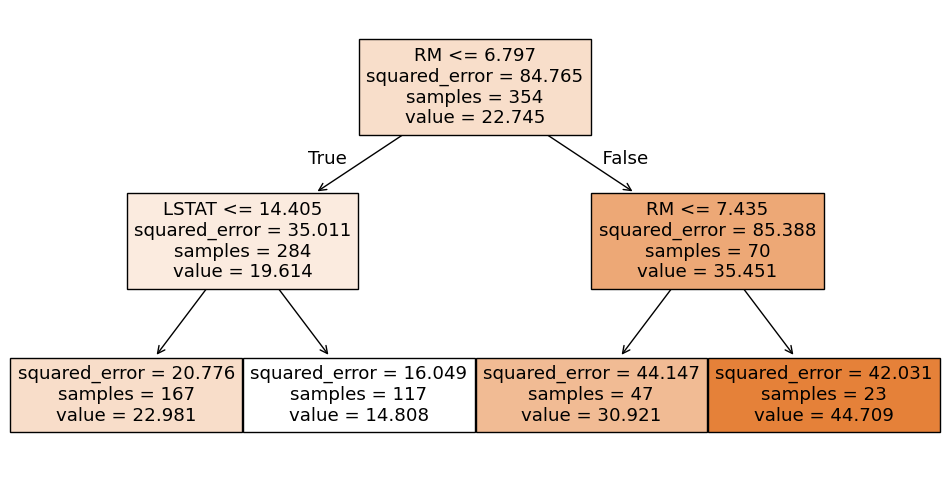

In [9]:
# 5 - Use plot_tree from tree API to display the rules of the decision tree
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(rdt, feature_names=feature_names, filled=True)
plt.show()

Which inputs / features are the most important?

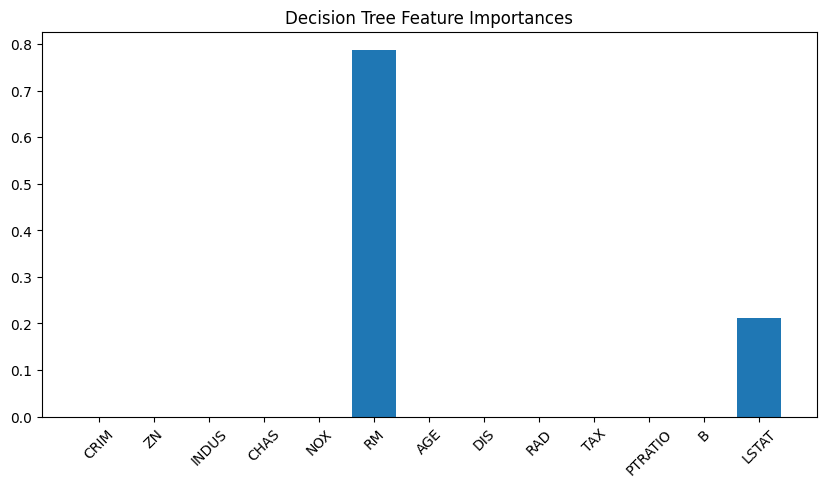

In [10]:
# 6 - Use features_importances values of the decision tree to plot an histogram showing the inputs / features importance
plt.figure(figsize=(10,5))
plt.bar(feature_names, rdt.feature_importances_)
plt.xticks(rotation=45)
plt.title("Decision Tree Feature Importances")
plt.show()

## 3 - Train several decision trees using increasing max_depth values: 50 trees using max_depth values from 1 to 50. Save $\mbox{MSE}$ and $R^2$ values evaluated on train and test sets for each DT. Once the 50 DTs have been trained, plot the curves of the two metrics according to the value of the decision tree maximum depth.

In [11]:
# 1 - Define some useful variables
max_depth_ls = [i for i in range(1,50)]
mse_train = []
mse_test = []
r2_train = []
r2_test = []

In [12]:
# 2 - Train the 50 DTs and save their respective MSE and R^2 values
for m in max_depth_ls :
    dt = DecisionTreeRegressor(max_depth=m, random_state=0)
    dt.fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))
    r2_train.append(r2_score(y_train, y_train_pred))
    r2_test.append(r2_score(y_test, y_test_pred))

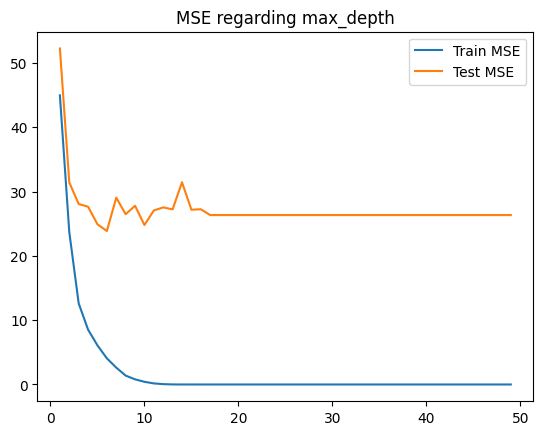

In [13]:
# 3 - Plot the MSE tran and test curves according to max_depth
plt.figure()
plt.plot(max_depth_ls, mse_train, label='Train MSE')
plt.plot(max_depth_ls, mse_test, label='Test MSE')
plt.title('MSE regarding max_depth')
plt.legend()
plt.show()

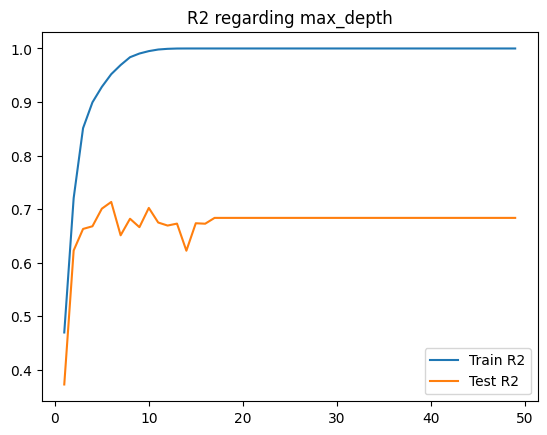

In [14]:
# 4 - Plot the R^2 train and test curves according to max depth
plt.figure()
plt.plot(max_depth_ls, r2_train, label='Train R2')
plt.plot(max_depth_ls, r2_test, label='Test R2')
plt.title('R2 regarding max_depth')
plt.legend()
plt.show()

What can you observe?

## 4 - Now switch to random forests and continue to vary the max_depth value as done previously for decision tree. Use 100 and 0 as the n_estimators and random_state values, respectively.

In [15]:
# 1 - Train a RF using 20 as max_depth value
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, random_state=0)

In [16]:
# 2 - Print MSE and R^2 errors / metrics for test set
y_pred_rf = rf.predict(X_test)
print('MSE : {}'.format(mean_squared_error(y_test, y_pred_rf)))
print('R2 : {}'.format(r2_score(y_test, y_pred_rf)))

MSE : 14.497125473684216
R2 : 0.8258927744705352


In [17]:
# 3 - Train the 50 RFs and save their respective MSE and R^2 values
max_depth_ls = [i for i in range(1,50)]
mse_train = []
mse_test = []
r2_train = []
r2_test = []

for m in max_depth_ls :
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=m, random_state=0)
    rf_model.fit(X_train, y_train)
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))
    r2_train.append(r2_score(y_train, y_train_pred))
    r2_test.append(r2_score(y_test, y_test_pred))

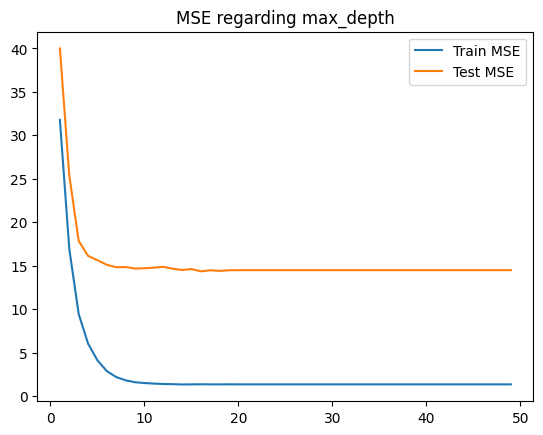

In [18]:
# 4 - Plot the MSE tran and test curves according to max_depth
plt.figure()
plt.plot(max_depth_ls, mse_train, label='Train MSE')
plt.plot(max_depth_ls, mse_test, label='Test MSE')
plt.title('MSE regarding max_depth')
plt.legend()
plt.show()

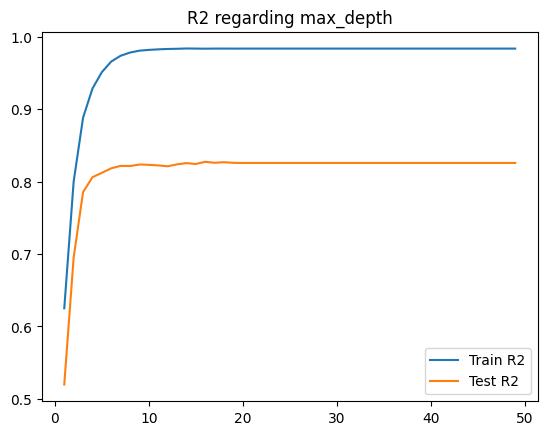

In [19]:
# 5 - Plot the R^2 train and test curves according to max depth
plt.figure()
plt.plot(max_depth_ls, r2_train, label='Train R2')
plt.plot(max_depth_ls, r2_test, label='Test R2')
plt.title('R2 regarding max_depth')
plt.legend()
plt.show()

What can you observe?

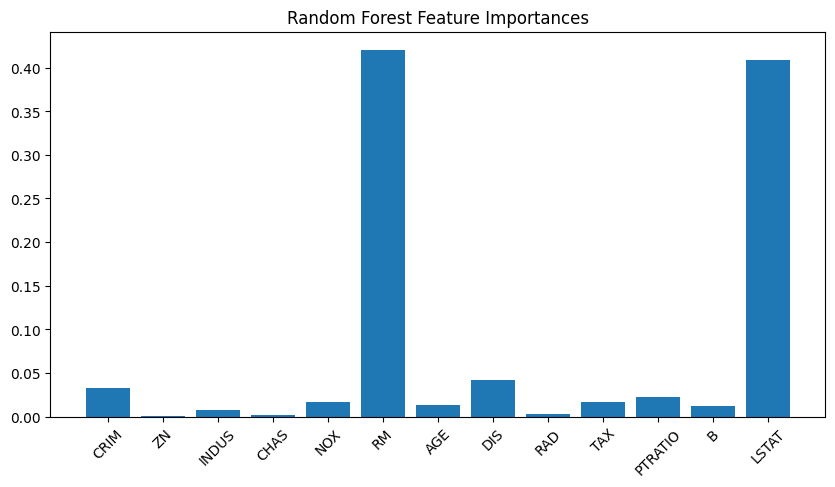

In [20]:
# 6 - Use features_importances values of the last random forest to plot an histogram showing the inputs / features importance
plt.figure(figsize=(10,5))
plt.bar(feature_names, rf_model.feature_importances_)
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importances")
plt.show()

## 5 - Let us show that scikit-learn simply aggregates the trees predictions of the forest by computing their average value.

In [21]:
# 1 - Train a random forest with same parameters as above
from sklearn.ensemble import RandomForestRegressor
rf_test = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=0)
rf_test.fit(X_train, y_train)

# 2 - Get access to each tree of the forest using parameter estimators_ of the RF - see scikit-learn
trees = rf_test.estimators_

# 3 - Compute the average value of the predictions given by the different trees and use it to compute R^2
tree_predictions = np.array([tree.predict(X_test) for tree in trees])
avg_predictions = np.mean(tree_predictions, axis=0)

In [22]:
# 4 - Compute R^2 score using the predictions given by the Random Forest trained in step 1
r2_manual = r2_score(y_test, avg_predictions)
r2_rf = r2_score(y_test, rf_test.predict(X_test))
print("Manual average prediction R2 score:", r2_manual)
print("Random forest prediction R2 score:", r2_rf)

Manual average prediction R2 score: 0.8258927744705352
Random forest prediction R2 score: 0.8258927744705352


## 6 - Rather than averaging the predictions of the different trees, let us try to learn how use different weights for the trees using a Linear Regression

The idea is to find the set of weights $w_1,\dots,w_B$  such that : $$ Y= P_{RF}(X) = \sum_{i=1,\dots,B} P_{DT_i} f_i(X)$$
where
* $B$ is the number of trees,
* $P_{RF}$ are the Random Forest's predictions,
* $P_{DT_i}$ are the predictions given by Decision Tree $i$.

In [23]:
# 1 - Let us define a function that define the predictions given by the different DTs as the new features
def new_features(forest, X):
    preds = np.array([tree.predict(X) for tree in forest.estimators_])
    return preds.T

In [24]:
# 2 - Define new train and test sets using the new_features / predictions of the RF for X_train and X_test , respectively
X_train2, X_test2 = new_features(rf_test, X_train), new_features(rf_test, X_test)

In [25]:
# 3 -  Train linear regression
from sklearn.linear_model import LinearRegression
meta_lr = LinearRegression()
meta_lr.fit(X_train2, y_train)

LinearRegression()

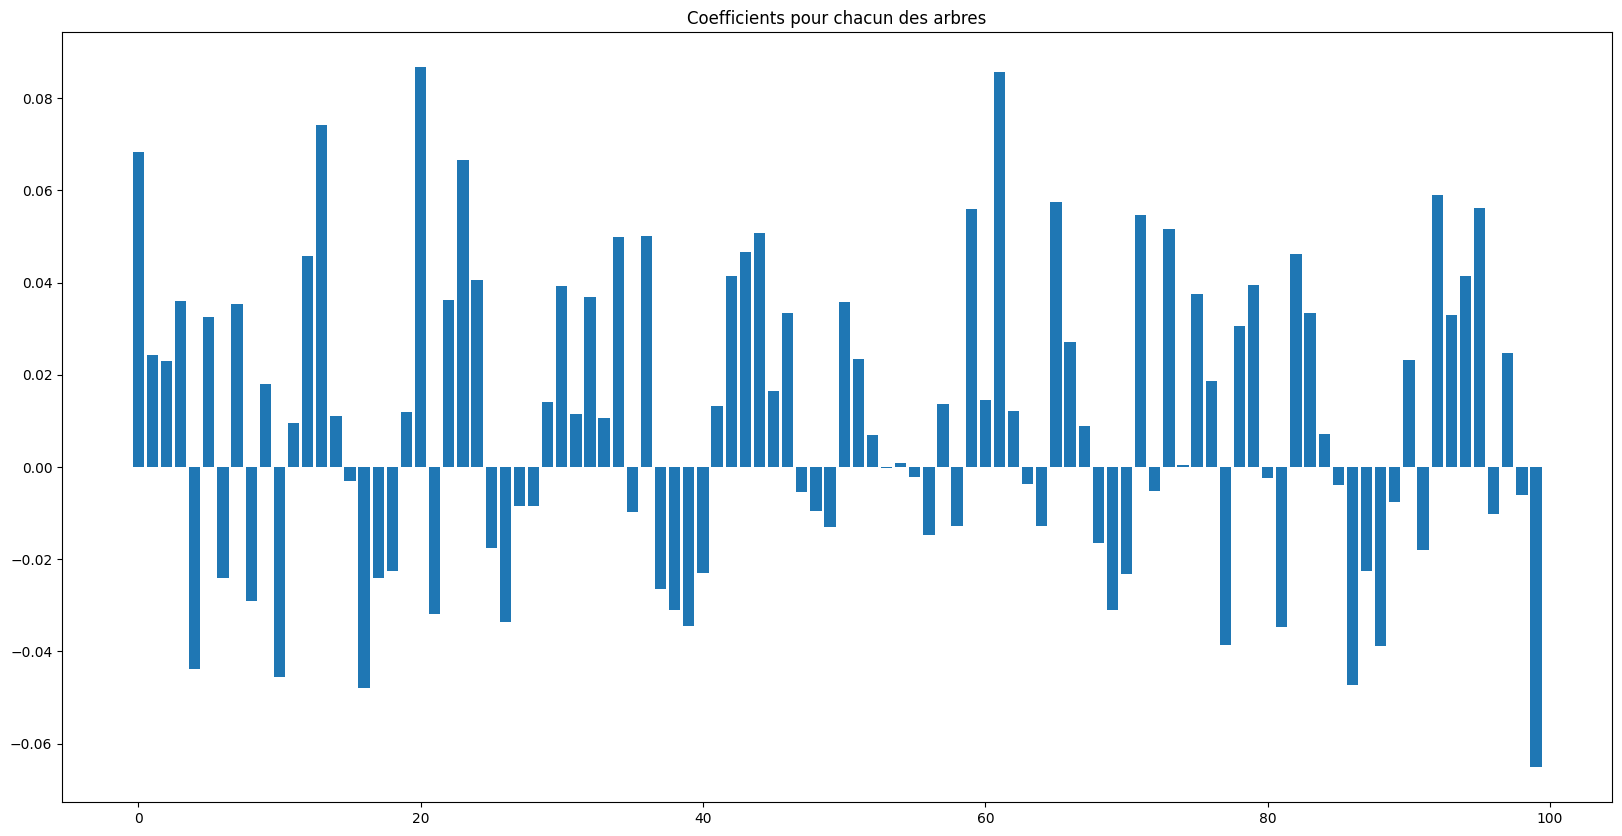

In [26]:
# 4 - Show the weights values / linear regression coefficients
# On printe les coeffs :
plt.figure(figsize = (20,10))
plt.bar(range(len(meta_lr.coef_)), meta_lr.coef_)
plt.title('Coefficients pour chacun des arbres')
plt.show()

In [27]:
# 5 - Predict values for the new test set using linear regression
y_pred = meta_lr.predict(X_test2)

In [28]:
# 6 - Print MSE and R^2 errors / metrics for the new test set
print('MSE (Meta LR) :', mean_squared_error(y_test, y_pred))
print('R2 (Meta LR) :', r2_score(y_test, y_pred))

MSE (Meta LR) : 13.10400825652834
R2 (Meta LR) : 0.842623799800807


## 7 - Try to replace Linear Regression with Lasso Regression

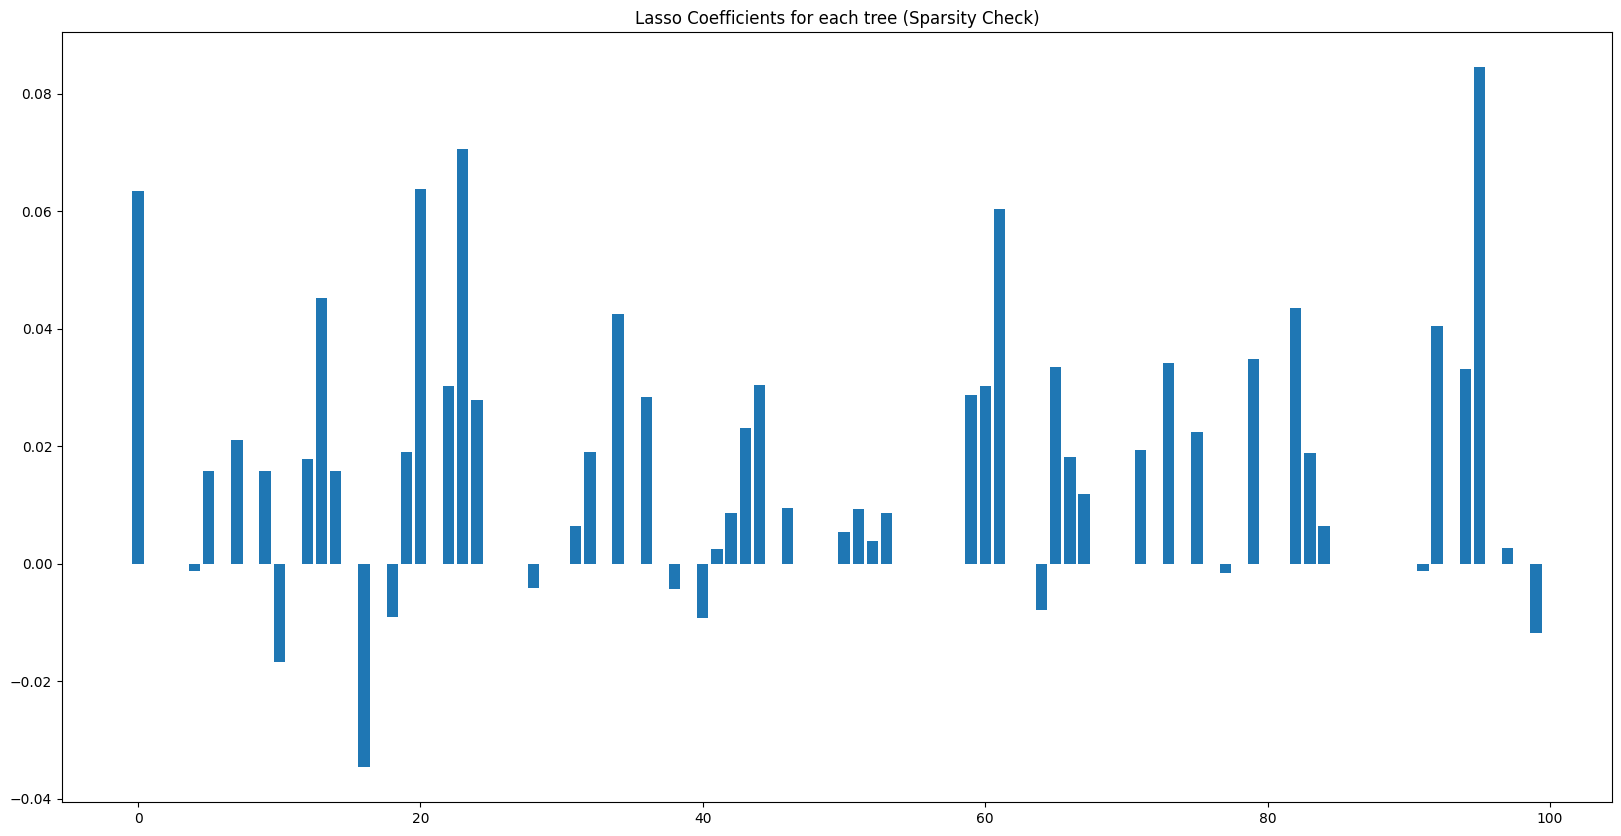

Number of trees with non-zero weight: 53 / 100


In [31]:
from sklearn.linear_model import Lasso

# 1 - Train Lasso regression (meta-model)
# Increased max_iter to ensure convergence
meta_lasso = Lasso(alpha=0.1, max_iter=10000)
meta_lasso.fit(X_train2, y_train)

# 2 - Show the weights values / lasso regression coefficients
plt.figure(figsize=(20, 10))
plt.bar(range(len(meta_lasso.coef_)), meta_lasso.coef_)
plt.title('Lasso Coefficients for each tree (Sparsity Check)')
plt.show()

# Count non-zero weights
non_zero = np.sum(meta_lasso.coef_ != 0)
print(f"Number of trees with non-zero weight: {non_zero} / {len(meta_lasso.coef_)}")

In [30]:
# 3 - Predict and Evaluate
y_pred_lasso = meta_lasso.predict(X_test2)

print('MSE (Meta Lasso) :', mean_squared_error(y_test, y_pred_lasso))
print('R2 (Meta Lasso) :', r2_score(y_test, y_pred_lasso))

MSE (Meta Lasso) : 14.342901382120715
R2 (Meta Lasso) : 0.8277449712208955


###  Lab 2 Conclusion: Decision Trees & Random Forests

#### 1. Feature Importances

*   **RM** (average number of rooms per dwelling) and **LSTAT** (% lower status of the population) are by far the most important features in predicting home values.
*   RM represents the size of the house, and LSTAT represents the socioeconomic standing of the neighborhood. Together they capture the main drivers of real estate value.

#### 2. Observations on Tree Depth (Overfitting vs. Generalization)

*   **Single Decision Tree:** As `max_depth` increases from 1 to 50, the training error drops to 0 and training $R^2$ reaches 1.0. However, the test set performance peaks early (around depth 5–6) and then degrades significantly. This demonstrates that deep individual decision trees quickly overfit, learning noise rather than patterns.
*   **Random Forest:** In contrast, as `max_depth` increases, the test set curves stabilize and remain high ($R^2 \approx 0.82$). Because Random Forests use bootstrap aggregating (bagging) and select random subsets of features, they successfully reduce model variance, preventing the overfitting seen in individual trees.

#### 3. Simple Averaging vs. Weighted Meta-Modeling

*   **Simple Averaging:** We verified that extracting the 100 individual trees (`.estimators_`) and averaging their predictions manually results in the exact same $R^2$ score (0.8258) as the Random Forest model. This confirms the RF regressor is mathematically a uniform average of its component trees.
*   **Weighted Stacking (Linear Regression):** When we trained a meta Linear Regression model to learn optimal weights for each tree instead of simple uniform averaging, the test set performance improved from an $R^2$ of 0.8258 to **0.8426**.

#### 4. General Conclusion

Ensemble methods (Random Forests) resolve the high variance and overfitting problems of single decision trees. Furthermore, rather than simple averaging, learning optimal weights for tree predictions via a meta-learning model (such as Linear Regression or Lasso) can squeeze even higher prediction accuracy from the forest.